In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
from collections import defaultdict
import matplotlib.pylab as pl


In [21]:
output_folder=("../PhysiCell/results/stochastic_cell_cycle/cell_volumes.csv")
pc_df = pd.read_csv(output_folder,float_precision='round_trip').sort_values(by=['dt']).reset_index(drop=True)
pc_df


,id,x,y,z,total_volume,current_phase,dt
0,0.0,0.000000,0.000000,0.000000,523.600000,4.0,0.0
1,0.0,0.000000,0.000000,0.000000,523.600000,4.0,30.0
2,0.0,0.000000,0.000000,0.000000,523.600000,4.0,60.0
3,0.0,0.000000,0.000000,0.000000,523.600000,10.0,90.0
4,0.0,0.000000,0.000000,0.000000,548.770598,10.0,120.0
...,...,...,...,...,...,...,...
359,8.0,-0.065806,6.107596,6.814443,514.907288,4.0,2880.0
360,12.0,-1.511294,-3.775737,13.496676,391.869285,10.0,2880.0
361,0.0,9.720622,-4.832263,0.151310,901.593933,10.0,2880.0
362,9.0,-6.461507,0.928968,-9.185060,723.570967,10.0,2880.0


In [22]:
# Normalize time to hours
pc_df['dt'] = pc_df['dt'] / 60
pc_init_vol = 523.6

# Compute average volume per time step (normalized)
pc_avg_vol = pc_df.groupby('dt')['total_volume'].mean()
pc_avg_vol

dt
0.0     523.600000
0.5     523.600000
1.0     523.600000
1.5     523.600000
2.0     548.770598
           ...    
46.0    585.305860
46.5    600.546126
47.0    560.485748
47.5    528.223327
48.0    545.425482
Name: total_volume, Length: 97, dtype: float64

In [23]:
pc_dts = pc_df['dt'].unique()
pc_vols = (pc_avg_vol / pc_init_vol * 100).tolist()
pc_vols

[100.0,
 100.0,
 100.0,
 100.0,
 104.80721889523561,
 111.75430643550021,
 119.65086060782477,
 127.75889924243413,
 135.63744259836432,
 143.03856634589556,
 149.83812778569202,
 155.98981615718702,
 161.49486355621337,
 166.3822457372026,
 170.6958874550576,
 174.48652602148547,
 177.80665611094756,
 180.7074981645178,
 183.2372829650679,
 185.44038088422752,
 187.35696300390842,
 189.02298787313583,
 190.47037903690764,
 191.72730613598205,
 192.8185140751366,
 193.76566572734092,
 194.587677415758,
 195.3010353773094,
 195.92008716575793,
 196.4573055785054,
 98.46176245721087,
 98.66407533775596,
 101.24328171624637,
 104.86924659109388,
 108.94983940692711,
 113.1187318498415,
 117.1577431288986,
 120.94491341599583,
 124.4199077367964,
 127.56107652003487,
 130.3703417581551,
 132.86332402782458,
 90.04197882256956,
 91.33033025499915,
 92.45859487351859,
 93.68177393199095,
 96.32769823282261,
 101.08361163795085,
 107.23425949103707,
 115.07698050389419,
 123.35084324627401,
 

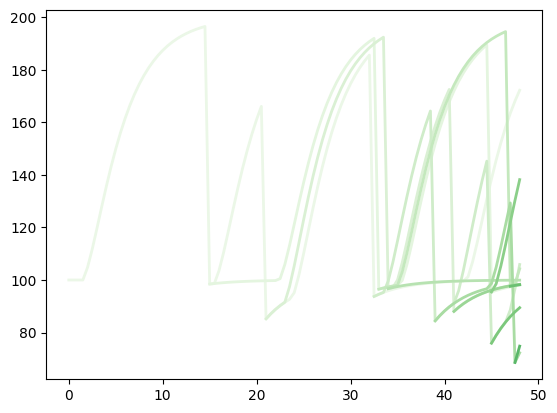

In [24]:
pc_init_vol = pc_df.iloc[0,4]
pc_group =  pc_df.groupby(['id']).groups.items()
num_cels = len(pc_group)
colors = pl.cm.Greens(np.linspace(0,1,num_cels*2))
j=2
for cell_id,idx in pc_group:
    vols = []
    dts = []
    for i in idx.values:
        vols.append((pc_df.loc[i,'total_volume']/pc_init_vol)*100)
        dts.append(pc_df.loc[i,'dt'])
    # plt.plot(dts,vols,label="PhysiCell", color=colors[j] ,linewidth=2)
    if cell_id!=num_cels-1:
        plt.plot(dts,vols, color=colors[j] ,linewidth=2)
    else:
        plt.plot(dts,vols, color=colors[j],label = 'PhysiCell' ,linewidth=2)
    j+=1

In [25]:
output_folder=("../Biodynamo/unit_test_cellcycle_stoch/new_results/output/")
cell_indices = [0, 2, 3, 4]
all_dfs = []

for idx in cell_indices:
    fname = os.path.join(output_folder, f'cell-{idx}.csv')
    df = pd.read_csv(fname, names=['timestep', 'volume', 'Phase', 'Age'], header=None)
    df['cell_id'] = idx
    all_dfs.append(df)

# Concatenate all individual DataFrames into one
combined_df = pd.concat(all_dfs, ignore_index=True)
grouped = combined_df.groupby('timestep').agg(
    total_volume=('volume', 'sum'),
    n_cells=('cell_id', 'nunique')  # number of unique cells at each timestep
)

# Calculate average volume per cell
grouped['avg_volume_per_cell'] = grouped['total_volume'] / grouped['n_cells']
grouped['avg_volume_per_cell'] = grouped['avg_volume_per_cell'] / 523.599

# Reset index to get 'timestep' as a column
bd_df = grouped.reset_index()

bd_df

,timestep,total_volume,n_cells,avg_volume_per_cell
0,0.01,523.599,1,1.000000
1,0.02,523.599,1,1.000000
2,0.03,523.599,1,1.000000
3,0.04,523.599,1,1.000000
4,0.05,523.599,1,1.000000
...,...,...,...,...
4795,47.96,2926.802,4,1.397444
4796,47.97,2929.877,4,1.398913
4797,47.98,2932.949,4,1.400379
4798,47.99,2936.016,4,1.401844


In [26]:
output_folder=("../Chaste/unit_test_cellcycle_stoch/results/cellcycle_stochastic.dat")
ch_df = pd.DataFrame(columns=["dt","id","x","y","z","g1_duration","s_duration","g2_duration","m_duration","current_phase","target_area","volume"])
with open(output_folder, "r") as f:
    for line in f.read().splitlines():
        data = line.split()
        data = [float(x) if x.replace('.', '', 1).isdigit() else x for x in data]
        dt = data[0]
        for i in range(0,len(data)//11):
            row = {'dt': dt, 'id': data[1+11*i], 'x': data[2+11*i], 'y': data[3+11*i], 'z': data[4+11*i], 'g1_duration': data[5+11*i], 's_duration': data[6+11*i], 'g2_duration': data[7+11*i], 'm_duration': data[8+11*i], 'current_phase': data[9+11*i], 'target_area': data[10+11*i], 'volume': data[11+11*i]}
            row = pd.Series(row)
            df2 = pd.DataFrame(row).transpose()

            ch_df =pd.concat([ch_df,df2],ignore_index=True)
ch_df

,dt,id,x,y,z,g1_duration,s_duration,g2_duration,m_duration,current_phase,target_area,volume
0,0.0,0.0,0.0,0.0,0.1,7.25521,6.32044,2.80048,2.1526,G1,0.523599,0.523599
1,0.1,0.0,0.0,0.0,3.0,7.25521,6.32044,2.80048,2.1526,G1,0.523599,0.523599
2,0.2,0.0,0.0,0.0,3.0,7.25521,6.32044,2.80048,2.1526,G1,0.523599,0.523599
3,0.3,0.0,0.0,0.0,3.0,7.25521,6.32044,2.80048,2.1526,G1,0.523599,0.523599
4,0.4,0.0,0.0,0.0,3.0,7.25521,6.32044,2.80048,2.1526,G1,0.523599,0.523599
...,...,...,...,...,...,...,...,...,...,...,...,...
977,47.9,3.0,1.16217,-0.244869,2.75488,8.11108,5.51073,2.80928,2.18411,S,0.684275,0.682703
978,48.0,0.0,-1.05816,-0.324506,2.78837,6.25944,5.19225,2.93086,1.7571,S,0.826768,0.825525
979,48.0,1.0,0.071579,-0.193753,2.99288,6.5616,7.18621,2.98239,1.83951,S,0.797384,0.795568
980,48.0,2.0,-0.532432,0.750143,2.85549,7.94535,5.58975,3.4465,1.86309,S,0.717101,0.715756


In [27]:
output_folder=("../Tisim/unit_test_cellcycle_stoch/cell cycle stochastic.csv")
data = pd.read_csv(output_folder, header=0)
time_steps = data['time (hour)']
volume_columns = data.columns[1:]  # Assuming all other columns are cell volumes

average_volumes = data[volume_columns].mean(axis=1, skipna=True)
initial_total_volume = average_volumes.iloc[0]

percentage_total_volumes = (average_volumes / initial_total_volume)*100
# print(percentage_total_volumes)
# Create a new DataFrame with time steps and percentage of total volumes
ts_df = pd.DataFrame({
    'timestep': time_steps,
    'volumes': percentage_total_volumes
})
ts_df



,timestep,volumes
0,1,100.00000
1,2,100.00000
2,3,100.00000
3,4,100.00000
4,5,100.00000
5,6,100.00000
6,7,119.55800
7,8,138.40700
8,9,154.09300
9,10,167.03500


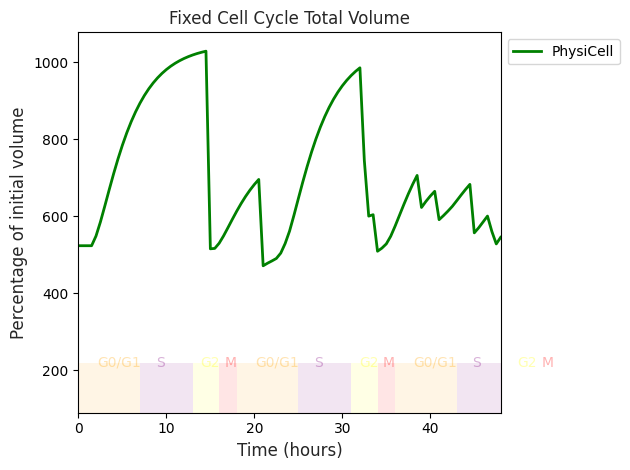

In [28]:
fig, ax = plt.subplots()



# Plot PhysiCell
ax.plot(pc_dts, pc_avg_vol, label="PhysiCell", color='green', linewidth=2)

# # Chaste
# ch_init_vol = ch_df.loc[0, "volume"]
# ch_avg_vol = ch_df.groupby('dt')['volume'].mean()
# dts = ch_avg_vol.index
# vols = (ch_avg_vol / ch_init_vol * 100).tolist()
# ax.plot(dts, vols, label="Chaste", color='blue', linewidth=2, alpha=0.5)

# # TiSim
# ax.plot(ts_df['timestep'], ts_df['volumes'], label="TiSim", color='#ffd343', linewidth=2)

# # BioDynaMo
# ax.plot(bd_df['timestep'], bd_df["avg_volume_per_cell"], label="Biodynamo", color="red")

# Add phase background rectangles (G0/G1, S, G2, M)
for i in range(3):  # repeat 3 cell cycles
    base = 18 * i
    phases = [
        (base, 7, 'orange', 'G0/G1'),
        (base + 7, 6, 'purple', 'S'),
        (base + 13, 3, 'yellow', 'G2'),
        (base + 16, 2, 'red', 'M'),
    ]
    for x, w, color, label in phases:
        ax.add_patch(patches.Rectangle((x, 50), w, 170, facecolor=color, alpha=0.1, edgecolor=None))
        if label in ['G2', 'M']:
            ax.text(x + w * 0.3, 210, label, color=color, alpha=0.3)
        else:
            ax.text(x + w * 0.3, 210, label, color=color, alpha=0.3)

# Final plot formatting
ax.set_xlim(0, 48)
ax.set_ylim(90)
ax.set_xlabel("Time (hours)", fontsize=12, color='#262626')
ax.set_ylabel("Percentage of initial volume", fontsize=12, color='#262626')
ax.set_title('Fixed Cell Cycle Total Volume', color='#262626')
ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig("stochastic.png", dpi=200)
plt.show()